<a href="https://colab.research.google.com/github/DhairyaDave08/Machine-Learning/blob/main/Projects/Project_1/Project_1_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Impact of AI on Students**

## Objective
Analyze how Generative AI usage affects student outcomes across three dimensions:
- **GPA** (regression)
- **Skill Retention Score** (regression)
- **Burnout Risk Level** (classification)

Dataset source: [Kaggle — AI Impact on Students](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students)

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Load Dataset**
Downloading the dataset from Kaggle using `kagglehub`.

In [129]:
import kagglehub
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-students


In [130]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/ai-impact-on-students
['ai_student_impact_dataset (1).csv']


## **2. Exploratory Data Analysis**
Checking the shape, null values, and duplicate rows before any processing.

In [131]:
import pandas as pd

df = pd.read_csv("/kaggle/input/ai-impact-on-students/ai_student_impact_dataset (1).csv")

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [132]:
#Finding the shape of the database
df.shape

(50000, 16)

In [133]:
df.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
df.drop("Student_ID", axis=1, inplace=True)

### Distribution of Skill Retention Score
Visualizing the target distribution to check for skewness.

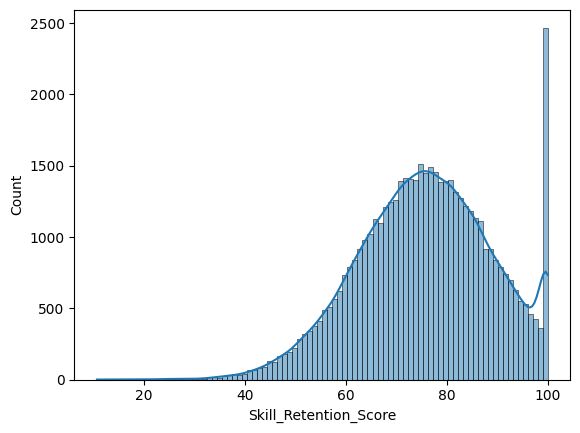

<Axes: xlabel='Post_Semester_GPA', ylabel='Count'>

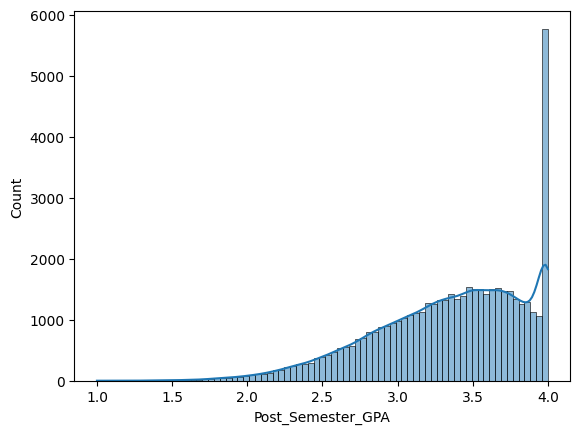

In [136]:
sns.histplot(df["Skill_Retention_Score"],kde=True)
plt.show()
sns.histplot(df["Post_Semester_GPA"],kde=True)

## **3. Feature Engineering**
Creating three derived features:
- `Total_Study_Time` — combined AI + traditional study hours
- `AI_Study_Ratio` — proportion of study time spent on GenAI tools
- `Anxiety_per_Hour` — anxiety level normalized by study hours

In [137]:
df["Total_Study_Time"] = (df["Weekly_GenAI_Hours"] + df["Traditional_Study_Hours"])
df["AI_Study_Ratio"] = (df["Weekly_GenAI_Hours"] /(df["Traditional_Study_Hours"] + 1))
df["Anxiety_per_Hour"] = (df["Anxiety_Level_During_Exams"] /(df["Traditional_Study_Hours"] + 1))
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,Total_Study_Time,AI_Study_Ratio,Anxiety_per_Hour
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,31.44,2.553122,0.657174
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,17.77,0.063456,0.509915
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,31.61,1.873128,0.792952
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,17.05,0.112138,0.123229
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,21.84,0.685609,0.295203


## **4. Encoding Categorical Variables**

- **Ordinal columns** (`Year_of_Study`, `Prompt_Engineering_Skill`): encoded with a meaningful order using `OrdinalEncoder`
- **Nominal columns** (`Major_Category`, `Primary_Use_Case`, `Institutional_Policy`): encoded using One-Hot Encoding with `drop="first"` to avoid multicollinearity
- **Binary column** (`Paid_Subscription`): cast directly to `int`

In [138]:
ordinal_cols = ["Year_of_Study","Prompt_Engineering_Skill"]
nominal_cols = ["Major_Category","Primary_Use_Case","Institutional_Policy"]
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(categories=[["Freshman", "Sophomore", "Junior", "Senior", "Graduate"],["Beginner", "Intermediate", "Advanced"]])

df[ordinal_cols] = ord_enc.fit_transform(df[ordinal_cols])
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop="first", sparse_output=False)

encoded = ohe.fit_transform(df[nominal_cols])

encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(nominal_cols),index=df.index)
df = df.drop(columns=nominal_cols)
df["Paid_Subscription"] = df["Paid_Subscription"].astype(int)
df = pd.concat([df, encoded_df], axis=1)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year_of_Study                               50000 non-null  float64
 1   Pre_Semester_GPA                            50000 non-null  float64
 2   Weekly_GenAI_Hours                          50000 non-null  float64
 3   Prompt_Engineering_Skill                    50000 non-null  float64
 4   Tool_Diversity                              50000 non-null  int64  
 5   Paid_Subscription                           50000 non-null  int64  
 6   Traditional_Study_Hours                     50000 non-null  float64
 7   Perceived_AI_Dependency                     50000 non-null  int64  
 8   Anxiety_Level_During_Exams                  50000 non-null  int64  
 9   Post_Semester_GPA                           50000 non-null  float64
 10  Skill_Rete

In [140]:
df.head()

,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,3.0,2.418,23.31,0.0,1,1,8.13,5,6,2.393,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,3.821,1.12,2.0,5,0,16.65,3,9,3.696,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,3.398,21.26,0.0,2,0,10.35,5,9,3.499,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,3.0,3.789,1.82,1.0,4,0,15.23,2,2,4.000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,3.635,9.29,2.0,4,0,12.55,4,4,3.798,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


## 5. Define Targets
Separating the three prediction targets from the feature set.
- `y1` — Post Semester GPA (regression)
- `y2` — Skill Retention Score (regression)
- `y3` — Burnout Risk Level (classification)

In [141]:
regression_targets = ["Post_Semester_GPA","Skill_Retention_Score"]
classification_target = "Burnout_Risk_Level"

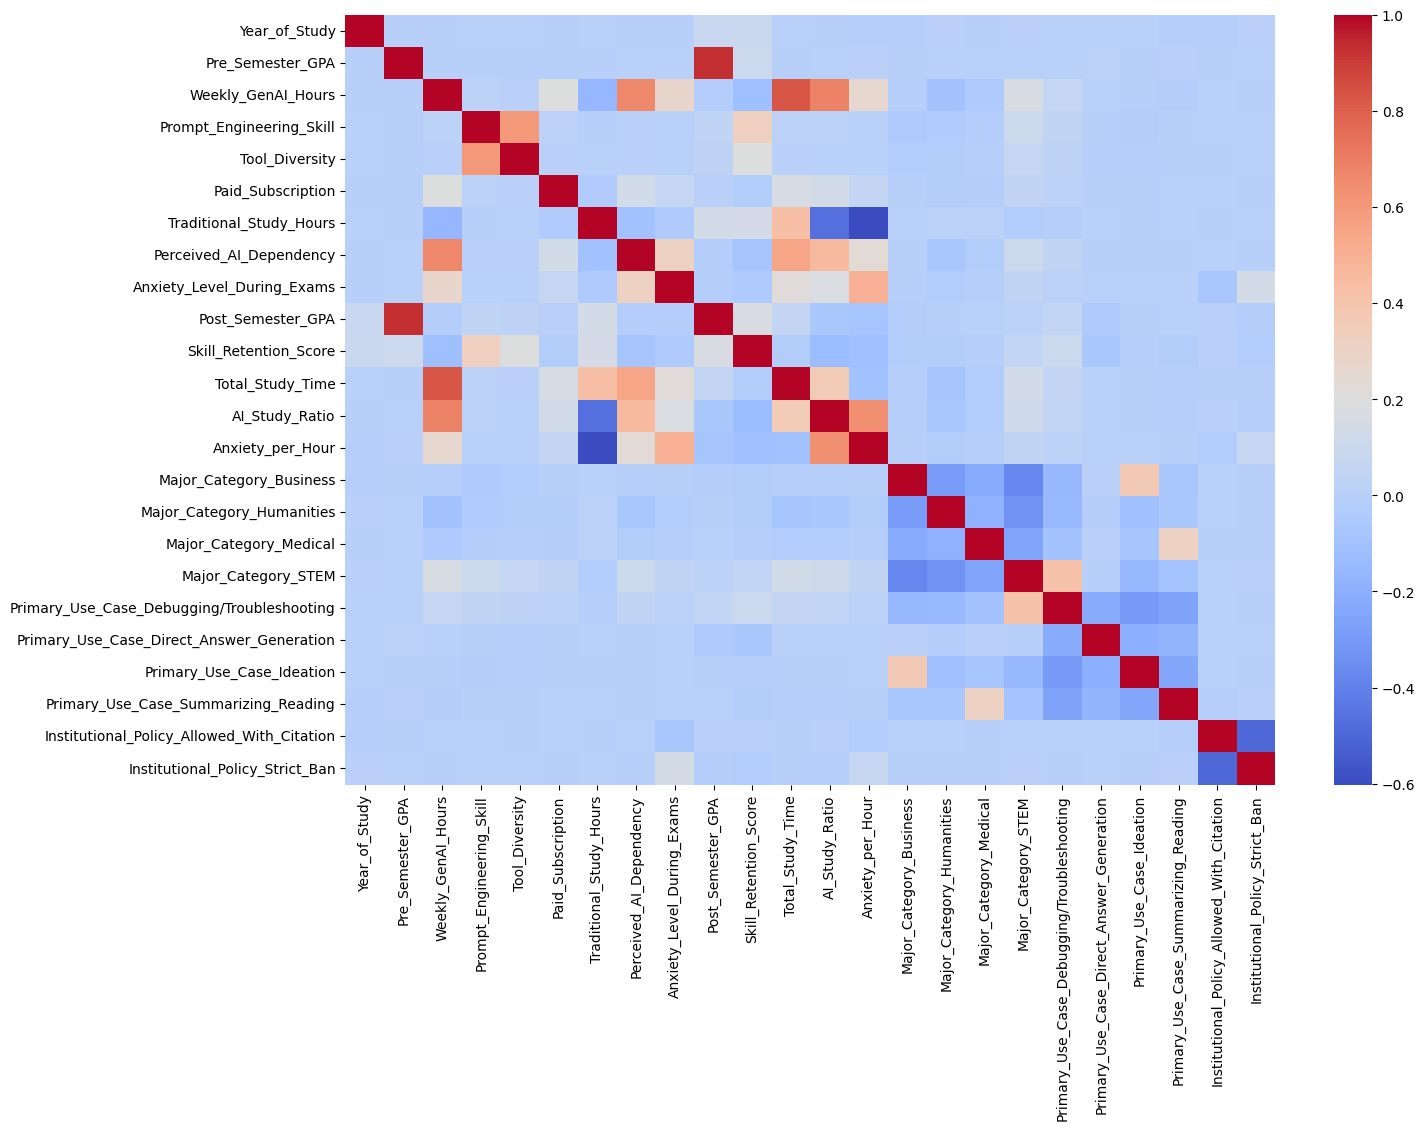

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")
plt.show()

In [143]:
y1 = df["Post_Semester_GPA"]
y2 = df["Skill_Retention_Score"]
y3 = df["Burnout_Risk_Level"]

In [144]:
X = df.drop(["Post_Semester_GPA","Skill_Retention_Score","Burnout_Risk_Level"],axis=1)

## **6. Train-Test Split**
Splitting data into 80% train / 20% test for each target independently.

In [145]:
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y1, test_size=0.2, random_state=42)

In [146]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42)

In [147]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y3, test_size=0.2, random_state=42)

## **7. Model Training & Evaluation**

### 7a. Linear Regression — Post Semester GPA

In [148]:
from sklearn.linear_model import LinearRegression
lr1 = LinearRegression()
lr1.fit(X_train1, y_train1)
pred1 = lr1.predict(X_test1)

In [149]:
from sklearn.metrics import r2_score, mean_absolute_error
print("R2 =", r2_score(y_test1, pred1))
print("MAE =", mean_absolute_error(y_test1, pred1))

R2 = 0.8947804732235684
MAE = 0.12494104300191634


### 7b. Linear Regression — Skill Retention Score

In [150]:
lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)
pred2 = lr2.predict(X_test2)

In [151]:
print("R2 =", r2_score(y_test2, pred2))
print("MAE =", mean_absolute_error(y_test2, pred2))

R2 = 0.17044889965236865
MAE = 9.77520906783373


### 7c. Logistic Regression — Burnout Risk Level

In [152]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train3, y_train3)
pred3 = clf.predict(X_test3)

In [153]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy =", accuracy_score(y_test3, pred3))
print(classification_report(y_test3, pred3))

Accuracy = 0.5383
              precision    recall  f1-score   support

        High       0.70      0.46      0.56      2536
         Low       0.54      0.49      0.51      3269
      Medium       0.49      0.62      0.55      4195

    accuracy                           0.54     10000
   macro avg       0.57      0.52      0.54     10000
weighted avg       0.56      0.54      0.54     10000



## **9. Visualizing Predictions**

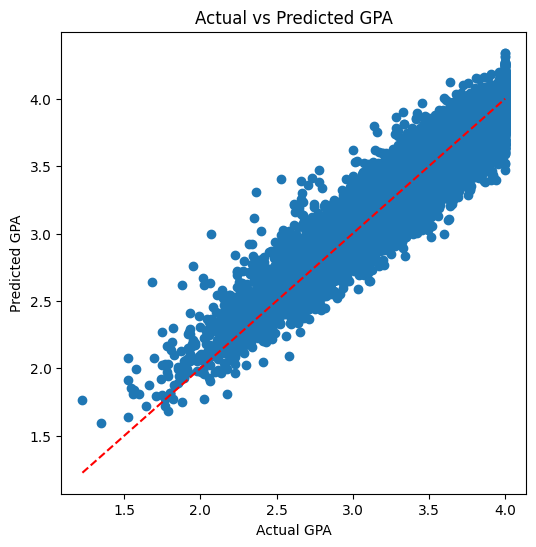

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test1, pred1)

plt.plot([y_test1.min(), y_test1.max()],[y_test1.min(), y_test1.max()],'r--')

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()

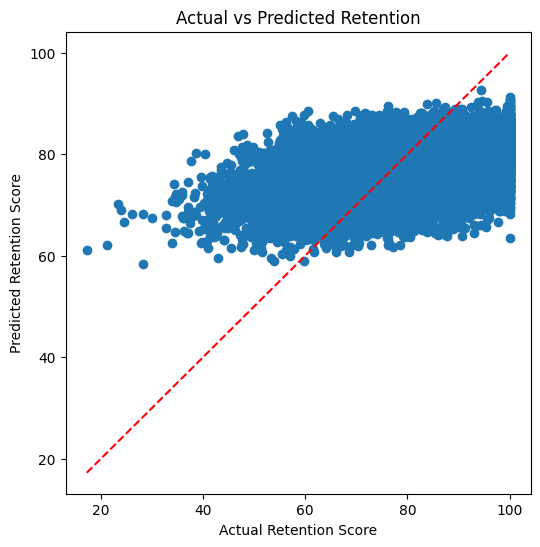

In [155]:
plt.figure(figsize=(6,6))

plt.scatter(y_test2, pred2)

plt.plot([y_test2.min(), y_test2.max()],[y_test2.min(), y_test2.max()],'r--')

plt.xlabel("Actual Retention Score")
plt.ylabel("Predicted Retention Score")
plt.title("Actual vs Predicted Retention")

plt.show()

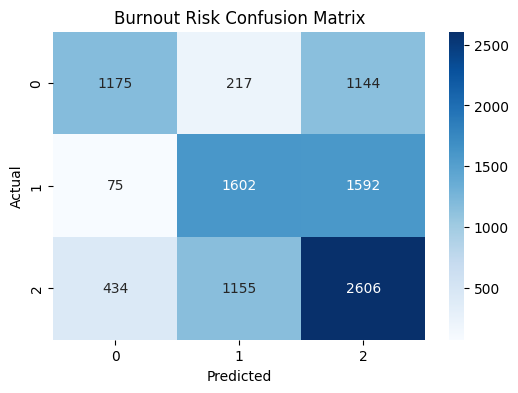

In [156]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test3,pred3)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Burnout Risk Confusion Matrix")

plt.show()

In [157]:
df["Predicted_Post_Semester_GPA"] = np.nan
df["Predicted_Skill_Retention_Score"] = np.nan
df["Predicted_Burnout_Risk_Level"] = np.nan
df.loc[y_test1.index, "Predicted_Post_Semester_GPA"] = pred1
df.loc[y_test2.index, "Predicted_Skill_Retention_Score"] = pred2
df.loc[y_test3.index, "Predicted_Burnout_Risk_Level"] = pred3
df.to_csv("student_predictions.csv", index=False)
from google.colab import files
files.download("student_predictions.csv")

/tmp/ipykernel_585/616730353.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Medium' 'Medium' 'High' ... 'High' 'Medium' 'Medium']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[y_test3.index, "Predicted_Burnout_Risk_Level"] = pred3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>